<a href="https://www.kaggle.com/code/sonawanelalitsunil/ml-model-comparison-on-telecom-data-ml-xgb?scriptVersionId=226946166" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-selling-phones-market-trends-and-insights/phone_data.csv


## Title:
## Best-Selling Smartphones: Market Trends & Consumer Insights

## Detailed Description:
This dataset provides an in-depth analysis of the top-selling smartphones in the market, highlighting key trends, consumer preferences, and sales performance. It includes essential features such as sales figures, brand popularity, market share, pricing strategies, and user ratings.

## Key Features:

✅ Sales Data: Number of units sold per smartphone model.

✅ Brand Analysis: Comparison of top smartphone brands and their market performance.

✅ Pricing Trends: Insights into pricing strategies and their impact on sales.

✅ Customer Ratings & Reviews: Consumer feedback on various smartphone models.

✅ Market Share Distribution: Breakdown of how different brands compete in the market.

✅ Regional Trends: Sales performance across different countries and regions.

## Potential Use Cases:

📊 Market Research & Competitive Analysis – Identify leading brands and their strategies.

📈 Business & Sales Forecasting – Predict smartphone sales trends and demand shifts.

📉 Consumer Behavior Analysis – Understand how price, features, and brand loyalty impact sales.

🛍️ Retail Strategy Optimization – Help retailers stock high-demand smartphones.

🤖 AI & ML Applications – Build recommendation models for smartphones based on consumer trends.

## Import dataset

In [2]:
df  = pd.read_csv('/kaggle/input/top-selling-phones-market-trends-and-insights/phone_data.csv')

In [3]:
df.head()

,index,date,duration,item,month,network,network_type
0,0,15/10/14 06:58,34.429,data,2014-11,data,data
1,1,15/10/14 06:58,13.000,call,2014-11,Vodafone,mobile
2,2,15/10/14 14:46,23.000,call,2014-11,Meteor,mobile
3,3,15/10/14 14:48,4.000,call,2014-11,Tesco,mobile
4,4,15/10/14 17:27,4.000,call,2014-11,Tesco,mobile


In [4]:
df.tail()

,index,date,duration,item,month,network,network_type
825,825,13/03/15 00:38,1.000,sms,2015-03,world,world
826,826,13/03/15 00:39,1.000,sms,2015-03,Vodafone,mobile
827,827,13/03/15 06:58,34.429,data,2015-03,data,data
828,828,14/03/15 00:13,1.000,sms,2015-03,world,world
829,829,14/03/15 00:16,1.000,sms,2015-03,world,world


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         830 non-null    int64  
 1   date          830 non-null    object 
 2   duration      830 non-null    float64
 3   item          830 non-null    object 
 4   month         830 non-null    object 
 5   network       830 non-null    object 
 6   network_type  830 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 45.5+ KB


In [6]:
df.describe()

,index,duration
count,830.000000,830.000000
mean,414.500000,117.804036
std,239.744656,444.129560
min,0.000000,1.000000
25%,207.250000,1.000000
50%,414.500000,24.500000
75%,621.750000,55.000000
max,829.000000,10528.000000


In [7]:
df.isnull().sum()

index           0
date            0
duration        0
item            0
month           0
network         0
network_type    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

index             int64
date             object
duration        float64
item             object
month            object
network          object
network_type     object
dtype: object

In [10]:
df.shape

(830, 7)

In [11]:
df.columns

Index(['index', 'date', 'duration', 'item', 'month', 'network',
       'network_type'],
      dtype='object')

## Data visualizations

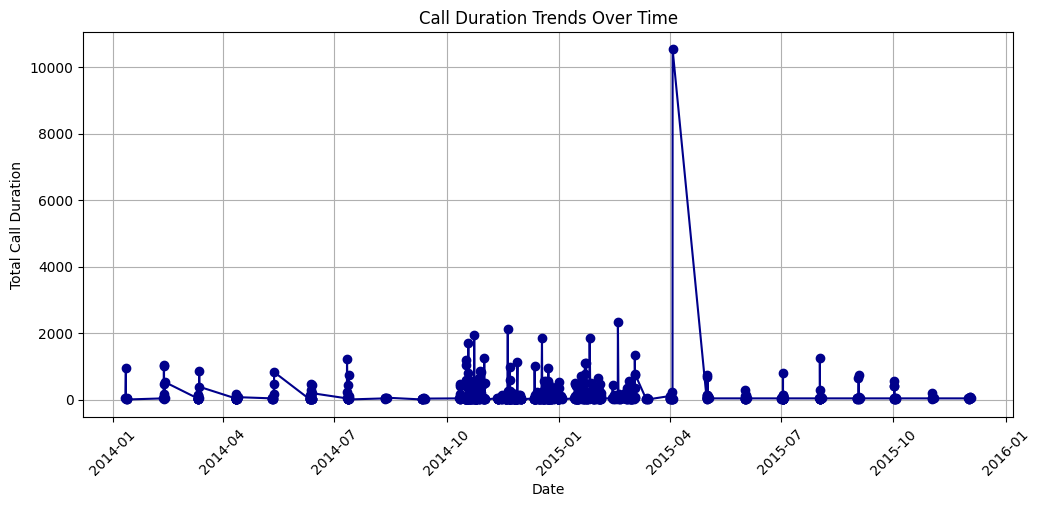

In [12]:
df["date"] = pd.to_datetime(df["date"])  
df_grouped = df.groupby("date")["duration"].sum()

plt.figure(figsize=(12, 5))
plt.plot(df_grouped.index, df_grouped.values, color="darkblue", marker="o", linestyle="-")
plt.xlabel("Date")
plt.ylabel("Total Call Duration")
plt.title("Call Duration Trends Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.show()


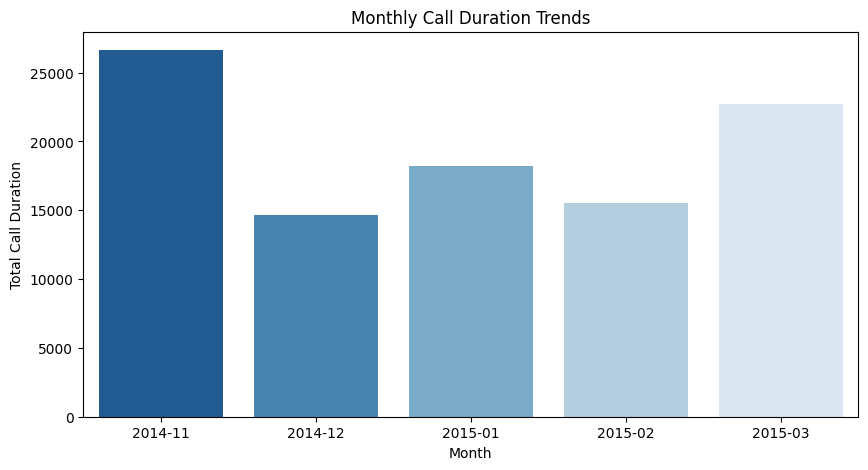

In [13]:
df_grouped = df.groupby("month")["duration"].sum().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=df_grouped.index, y=df_grouped.values, palette="Blues_r")
plt.xlabel("Month")
plt.ylabel("Total Call Duration")
plt.title("Monthly Call Duration Trends")
plt.show()

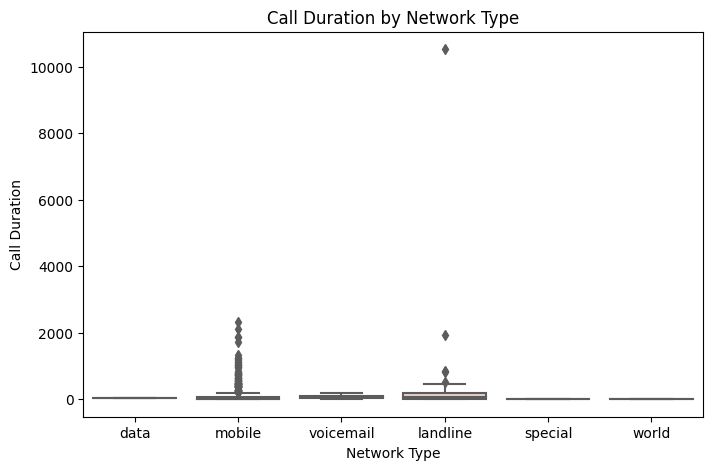

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="network_type", y="duration", data=df, palette="coolwarm")
plt.xlabel("Network Type")
plt.ylabel("Call Duration")
plt.title("Call Duration by Network Type")
plt.show()

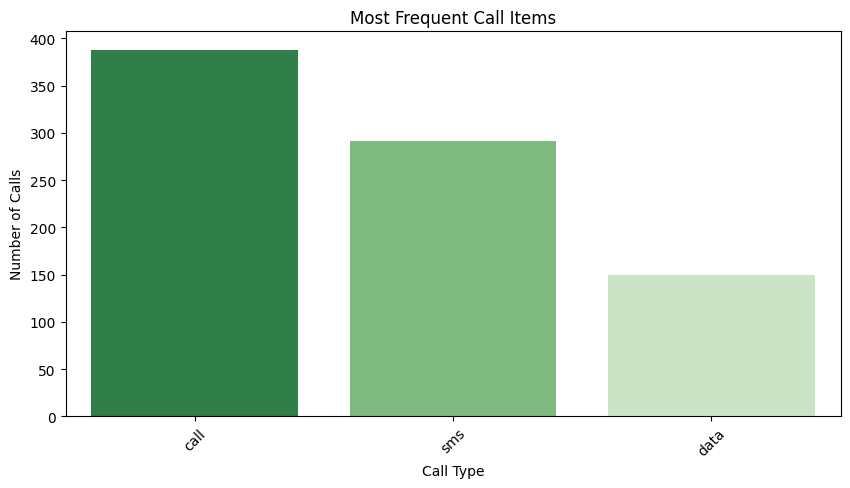

In [15]:
df_grouped = df["item"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=df_grouped.index, y=df_grouped.values, palette="Greens_r")
plt.xlabel("Call Type")
plt.ylabel("Number of Calls")
plt.title("Most Frequent Call Items")
plt.xticks(rotation=45)
plt.show()

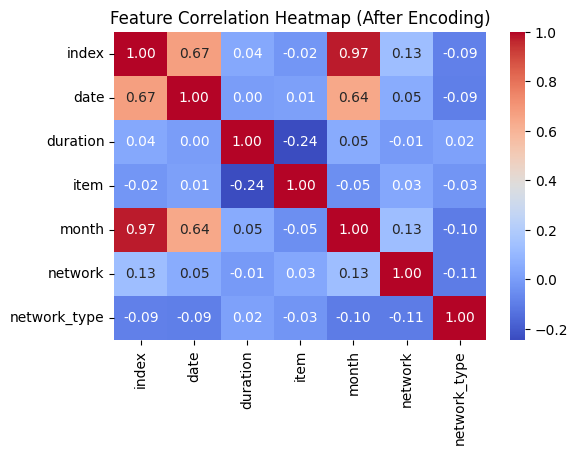

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in ['item', 'month', 'network', 'network_type']:
    df[col] = encoder.fit_transform(df[col])

# Now create heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (After Encoding)")
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score

In [18]:
df = df.drop(columns=['index', 'date'])  # Drop irrelevant columns

# Encode categorical columns
categorical_cols = ['item', 'month', 'network', 'network_type']
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Handle missing values (fill with median for numerical, mode for categorical)
df.fillna(df.median(numeric_only=True), inplace=True)

In [19]:
X = df.drop(columns=['duration'])  # Features
y = df['duration']  # Target variable

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization (for numerical features)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor(),
}

In [22]:
# Train and Evaluate Models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train
    y_pred = model.predict(X_test)  # Predict
# Compute regression metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "R2 Score": r2}

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

                                 MAE            MSE  R2 Score
Linear Regression         175.877539  705898.331647  0.019756
Decision Tree Regressor   169.018417  715264.149580  0.006751
Random Forest Regressor   168.845977  715226.527889  0.006803
Support Vector Regressor  159.585222  737791.378107 -0.024532
KNN Regressor             176.092771  714667.433976  0.007579


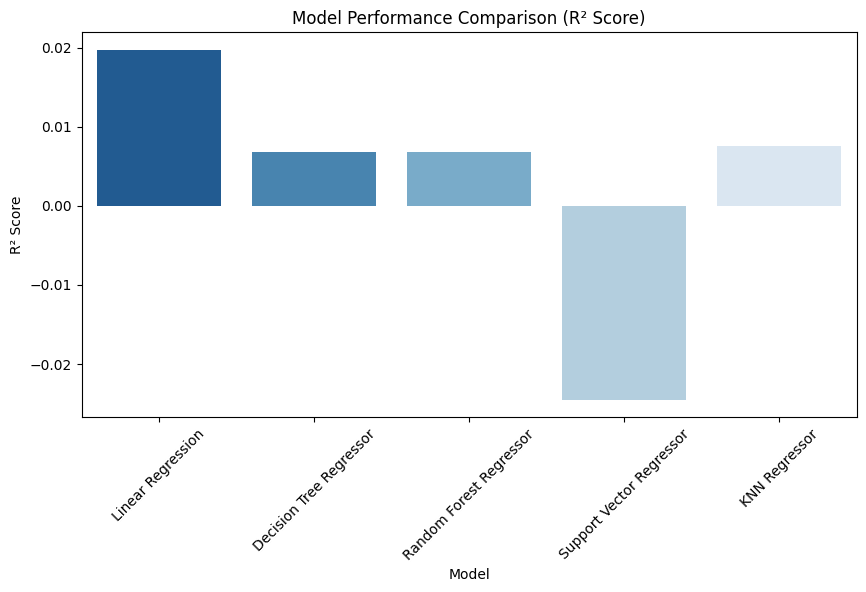

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["R2 Score"], palette="Blues_r")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (R² Score)")
plt.xticks(rotation=45)
plt.show()

## Thank you!!!!!...Pls Upvotes....!!